In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
TRAIN_IN = "train_clean.csv"
TEST_IN = "test_clear.csv"
RAW_IN = "../Bangladesh_Multi_Site_Air_Quality.csv"
TRAIN_OUT = "train_features.csv"
TEST_OUT = "test_features.csv"

In [52]:
SPIKE_THRESHOLD = 150
HORIZONS = [1, 2, 3]  # hours ahead

In [53]:
CITY_COORDS = {
    "Dhaka":      (23.8103, 90.4125),
    "Chittagong": (22.3569, 91.7832),
    "Sylhet":     (24.8949, 91.8687),
    "Rajshahi":   (24.3745, 88.6042),
    "Khulna":     (22.8456, 89.5403),
    "Barisal":    (22.7010, 90.3535),
}

In [54]:

# 16-point compass -> degrees (N=0, clockwise)
WD_TO_DEG = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
}

In [55]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

In [56]:
def build_distance_matrix(coords):
    cities = list(coords.keys())
    dist = pd.DataFrame(index=cities, columns=cities, dtype=float)
    for a in cities:
        for b in cities:
            if a == b:
                dist.loc[a, b] = np.nan
            else:
                dist.loc[a, b] = haversine(*coords[a], *coords[b])
    return dist

In [57]:
def plot_distance_heatmap(dist_matrix):
    """Display pairwise city distances in kilometres."""
    figure, axis = plt.subplots(figsize=(8, 6))
    image = axis.imshow(dist_matrix, cmap="YlOrRd")

    axis.set_xticks(range(len(dist_matrix.columns)))
    axis.set_xticklabels(dist_matrix.columns, rotation=45, ha="right")
    axis.set_yticks(range(len(dist_matrix.index)))
    axis.set_yticklabels(dist_matrix.index)
    axis.set_title("Distance Between Monitoring Cities (km)")

    for row in range(len(dist_matrix.index)):
        for column in range(len(dist_matrix.columns)):
            value = dist_matrix.iloc[row, column]
            if pd.notna(value):
                axis.text(column, row, f"{value:.0f}", ha="center", va="center", fontsize=8)

    figure.colorbar(image, ax=axis, label="Distance (km)")
    figure.tight_layout()
    plt.show()

In [58]:
def add_temporal_features(df):
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dayofweek"] = pd.to_datetime(df["datetime"]).dt.dayofweek
    return df

In [59]:
def add_lag_and_rolling_features(df):
    """Per-station lag & rolling stats of PM2.5. Assumes df sorted by station, datetime."""
    df = df.sort_values(["station", "datetime"])
    g = df.groupby("station")["PM2.5"]
 
    for lag in [1, 2, 3, 6, 24]:
        df[f"pm25_lag_{lag}"] = g.shift(lag)
 
    for window in [3, 6, 24]:
        df[f"pm25_roll_mean_{window}"] = (
            g.shift(1).rolling(window).mean().reset_index(level=0, drop=True)
        )
        df[f"pm25_roll_std_{window}"] = (
            g.shift(1).rolling(window).std().reset_index(level=0, drop=True)
        )
    return df

In [60]:
def add_wind_vectors(df):
    deg = df["wd"].map(WD_TO_DEG)
    theta = np.radians(deg)
    df["wind_u"] = -df["WSPM"] * np.sin(theta)
    df["wind_v"] = -df["WSPM"] * np.cos(theta)
    return df

In [61]:
def add_idw_spatial_lags(df, dist_matrix, power=2):
    """
    For each timestamp, compute IDW-weighted PM2.5 (and wind_u/v) from the
    OTHER 5 cities. Requires all 6 cities present at every timestamp
    (true for this dataset since it's a clean hourly panel).
    """
    pivot_pm25 = df.pivot(index="datetime", columns="station", values="PM2.5")
    pivot_u = df.pivot(index="datetime", columns="station", values="wind_u")
    pivot_v = df.pivot(index="datetime", columns="station", values="wind_v")
 
    cities = dist_matrix.index.tolist()
    idw_pm25 = pd.DataFrame(index=pivot_pm25.index, columns=cities, dtype=float)
    idw_u = pd.DataFrame(index=pivot_u.index, columns=cities, dtype=float)
    idw_v = pd.DataFrame(index=pivot_v.index, columns=cities, dtype=float)
 
    for city in cities:
        others = [c for c in cities if c != city]
        weights = np.array([1.0 / (dist_matrix.loc[city, o] ** power) for o in others])
        weights = weights / weights.sum()
 
        idw_pm25[city] = pivot_pm25[others].mul(weights, axis=1).sum(axis=1)
        idw_u[city] = pivot_u[others].mul(weights, axis=1).sum(axis=1)
        idw_v[city] = pivot_v[others].mul(weights, axis=1).sum(axis=1)
 
    idw_pm25 = idw_pm25.stack().rename("idw_pm25_neighbors").reset_index()
    idw_pm25.columns = ["datetime", "station", "idw_pm25_neighbors"]
    idw_u = idw_u.stack().rename("idw_wind_u_neighbors").reset_index()
    idw_u.columns = ["datetime", "station", "idw_wind_u_neighbors"]
    idw_v = idw_v.stack().rename("idw_wind_v_neighbors").reset_index()
    idw_v.columns = ["datetime", "station", "idw_wind_v_neighbors"]
 
    df = df.merge(idw_pm25, on=["datetime", "station"], how="left")
    df = df.merge(idw_u, on=["datetime", "station"], how="left")
    df = df.merge(idw_v, on=["datetime", "station"], how="left")
    return df

In [62]:
def add_spike_targets(df, horizons, threshold):
    """Binary spike label at t+k, per station."""
    df = df.sort_values(["station", "datetime"])
    for h in horizons:
        df[f"spike_t+{h}"] = (
            df.groupby("station")["PM2.5"].shift(-h) > threshold
        ).astype("Int64")  # nullable int: last rows per station will be NaN
    return df

In [63]:
def add_simple_pattern_features(df):
    """
    Lightweight stand-ins for ST-DBSCAN / Apriori-derived features that you
    can compute with plain pandas. Replace with real clustering/association
    rule outputs once you run those algorithms separately (see notes below).
    """
    # "Regional pressure" proxy: how many of the other 5 cities are ALSO
    # currently above a moderate threshold (elevated, not yet a full spike) -
    # a simple co-occurrence signal, precursor to full Apriori rule mining.
    ELEVATED = 100
    pivot = df.pivot(index="datetime", columns="station", values="PM2.5")
    elevated_count = (pivot > ELEVATED).sum(axis=1)
    n_stations = pivot.shape[1]
    elevated_frac_others = pd.DataFrame(index=pivot.index)
    for city in pivot.columns:
        others_elevated = elevated_count - (pivot[city] > ELEVATED).astype(int)
        elevated_frac_others[city] = others_elevated / (n_stations - 1)
    elevated_frac_others = elevated_frac_others.stack().rename(
        "regional_elevated_frac").reset_index()
    elevated_frac_others.columns = ["datetime", "station", "regional_elevated_frac"]
 
    df = df.merge(elevated_frac_others, on=["datetime", "station"], how="left")
    return df

City distance matrix (km):
             Dhaka  Chittagong  Sylhet  Rajshahi  Khulna  Barisal
Dhaka         NaN       214.0   190.5     194.0   139.4    123.5
Chittagong  214.0         NaN   282.3     394.5   236.6    151.7
Sylhet      190.5       282.3     NaN     335.0   328.6    288.6
Rajshahi    194.0       394.5   335.0       NaN   194.9    257.7
Khulna      139.4       236.6   328.6     194.9     NaN     84.9
Barisal     123.5       151.7   288.6     257.7    84.9      NaN


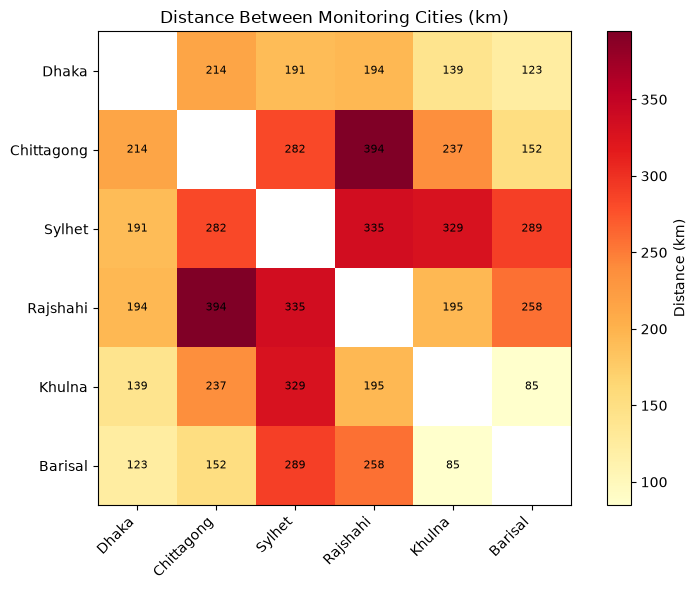

[train] dropped 144 edge rows with NaNs -> 179280 rows remain
[test] dropped 144 edge rows with NaNs -> 28800 rows remain

Saved train_features.csv ((179280, 44)) and test_features.csv ((28800, 41))

Feature columns:
 ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek', 'wind_u', 'wind_v', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3', 'pm25_lag_6', 'pm25_lag_24', 'pm25_roll_mean_3', 'pm25_roll_std_3', 'pm25_roll_mean_6', 'pm25_roll_std_6', 'pm25_roll_mean_24', 'pm25_roll_std_24', 'idw_pm25_neighbors', 'idw_wind_u_neighbors', 'idw_wind_v_neighbors', 'regional_elevated_frac', 'spike_t+1', 'spike_t+2', 'spike_t+3']
Spike rate at t+1: 0.881%
Spike rate at t+2: 0.881%
Spike rate at t+3: 0.881%


In [64]:
def run_pipeline(path_in, dist_matrix, is_train, label):
    df = pd.read_csv(path_in)
    df.columns = df.columns.astype(str).str.strip()

    # The cleaned files do not contain station; restore it from the raw dataset.
    if "station" not in df.columns:
        station_lookup = pd.read_csv(RAW_IN, usecols=["No", "station"])
        df = df.merge(station_lookup, on="No", how="left", validate="many_to_one")

    required = {"No", "station", "datetime", "PM2.5"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in {path_in}: {sorted(missing)}")
    if df["station"].isna().any():
        raise ValueError(f"Could not map station for all rows in {path_in}")

    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values(["station", "datetime"]).reset_index(drop=True)

    df = add_temporal_features(df)
    df = add_wind_vectors(df)
    df = add_lag_and_rolling_features(df)
    df = add_idw_spatial_lags(df, dist_matrix)
    df = add_simple_pattern_features(df)
    if is_train:
        df = add_spike_targets(df, HORIZONS, SPIKE_THRESHOLD)

    before = len(df)
    drop_columns = [f"pm25_lag_{max([1, 2, 3, 6, 24])}"]
    if is_train:
        drop_columns += [f"spike_t+{h}" for h in HORIZONS]
    df = df.dropna(subset=drop_columns)
    after = len(df)
    print(f"[{label}] dropped {before - after} edge rows with NaNs -> {after} rows remain")

    return df


if __name__ == "__main__":
    dist_matrix = build_distance_matrix(CITY_COORDS)
    print("City distance matrix (km):\n", dist_matrix.round(1))
    plot_distance_heatmap(dist_matrix)

    train_feat = run_pipeline(TRAIN_IN, dist_matrix, is_train=True, label="train")
    test_feat = run_pipeline(TEST_IN, dist_matrix, is_train=False, label="test")

    train_feat.to_csv(TRAIN_OUT, index=False)
    test_feat.to_csv(TEST_OUT, index=False)

    print(f"\nSaved {TRAIN_OUT} ({train_feat.shape}) and {TEST_OUT} ({test_feat.shape})")
    print("\nFeature columns:\n", [c for c in train_feat.columns if c not in
          ["No", "year", "month", "day", "hour", "datetime", "station"]])
    for h in HORIZONS:
        rate = train_feat[f"spike_t+{h}"].astype(float).mean() * 100
        print(f"Spike rate at t+{h}: {rate:.3f}%")